# <font color='green'> **MODELISATION DE L'ABSENCE DE POURBOIRE CHEZ LES CHAUFFEURS DE TAXI DE NEW YORK** </font>

![Image](https://media.lematin.ch/4/image/2023/11/10/51338278-59cd-4559-af66-8efbac423112.jpeg?auto=format%2Ccompress%2Cenhance&fit=max&w=1200&h=1200&rect=0%2C0%2C1024%2C683&s=7864704c0ca9395afa830274aeb70f2e)

# Contexte
Le projet porte sur la modélisation de la **générosité des clients** des taxis new-yorkais à partir de données de trajets.  
Il sera question pour nous dans ce projet de construire un modèle capable de prédire si un client **est_généreux** ou non, en se basant sur des variables telles que la durée du trajet, la distance, ou encore l’heure de la course...

Il aurait pu être question  pour nous de prédire si un client laissera un pourboire ou non, mais étant donné la problématique y relative, on se contentera de classifier un client de généreux ou non à partir de ses données

---

## Objectif
Prédire si un client sera classé **est_généreux** (donnera un pourboire supérieur ou égale à 20% du montant de la course) ou non, à partir des données de trajets de taxi à New York.

---

## Structure du Projet

### I. Chargement du Dataset

- Importation des bibliothèques nécessaires 
- Importation et fusion des deux parties du jeu de données 
- Création de la **target** binaire (ex: `Generous = tip_amount > 20%Total_amount`)

---

### II. Séparation du Dataset
- Séparation en deux sous-ensembles :
  - `Train set`
  - `Test set`
- (Utilisation de `train_test_split` de `sklearn`)

---

### III. Analyse exploratoire (EDA)
- Data understanding
- types de données
- Visualisation des distributions des variables:
  * Numériques
  * Catégorielles
- Analyse des dOutliers
- Analyse bivariée entre la target et les autres features
- Visualisation de la correlatione entre les variables numériques

---

### IV. Prétraitement
- Nettoyage des données (valeurs manquantes, types, outliers)
- Feature Engineering :
  - Création de variables à partir de la date/heure
- Encodage des variables catégorielles
- Standardisation / Normalisation si nécessaire

---

### V. Sélection et évaluation des modèles (Validation croisée)
- Mise en place d'une **Grid Search** avec **Validation Croisée**
- Entraînement et comparaison de plusieurs modèles :
  - KNN
  - Random Forest
  - Gradient Boosting
  - etc.
- Sélection des meilleurs hyperparamètres

---

### VI. Ré-entraînement final du modèle
- Entraînement sur **tout le Train Set** avec les meilleurs hyperparamètres

---

### VII. Évaluation sur le Test Set
- Prédictions finales
- Mesures de performance :
  - Accuracy, Precision, Recall, F1-Score
  - Matrice de confusion
  - ROC-AUC

---

### VIII. Conclusion & pistes d'amélioration
- Interprétation des résultats
- Analyse des erreurs
- Possibilités d'amélioration (plus de données, autres features, tuning...)



# <font color='brown'> I. CHARGEMENT DU DATASET </font>

In [7]:
# Manipulation de données
import pandas as pd
import numpy as np
import copy

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pour le feature engineering (extraction de date, heure, etc.)
from datetime import datetime

In [8]:
## **Chargement et fusion des deux parties du dataset**
d1=pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')
d2=pd.read_csv('nyc_preds_means.csv')

data=pd.concat([d1,d2], axis=1)
data=pd.DataFrame(data)
data

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,mean_duration,mean_distance,predicted_fare
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,13.0,0.0,0.5,2.76,0.00,0.3,16.56,22.847222,3.521667,16.434245
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,16.0,0.0,0.5,4.00,0.00,0.3,20.80,24.470370,3.108889,16.052218
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,6.5,0.0,0.5,1.45,0.00,0.3,8.75,7.250000,0.881429,7.053706
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,20.5,0.0,0.5,6.39,0.00,0.3,27.69,30.250000,3.700000,18.731650
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,16.5,0.5,0.5,0.00,0.00,0.3,17.80,14.616667,4.435000,15.845642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22694,14873857,2,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,3,0.61,1,N,48,186,...,4.0,1.0,0.5,0.00,0.00,0.3,5.80,8.594643,1.098214,7.799138
22695,66632549,2,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,1,16.71,2,N,132,164,...,52.0,0.0,0.5,14.64,5.76,0.3,73.20,59.560417,18.757500,52.000000
22696,74239933,2,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,1,0.42,1,N,107,234,...,4.5,0.0,0.5,0.00,0.00,0.3,5.30,6.609091,0.684242,6.130896
22697,60217333,2,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,1,2.36,1,N,68,144,...,10.5,0.0,0.5,1.70,0.00,0.3,13.00,16.650000,2.077500,11.707049


In [9]:
#Création d'une copy du jeu de données
df=copy.deepcopy(data)

#Traduction de ses colonnes en français
# Dictionnaire de traduction 
column_translation = {
    "Unnamed: 0": "ID",
    "VendorID": "ID_ven",
    "tpep_pickup_datetime": "dt_départ",
    "tpep_dropoff_datetime": "dt_arrivée",
    "passenger_count": "nb_pass",
    "trip_distance": "dist_trajet",
    "RatecodeID": "code_tarif",
    "store_and_fwd_flag": "données_différé",
    "PULocationID": "ID_dep",
    "DOLocationID": "ID_arr",
    "payment_type": "type_paie",
    "fare_amount": "montant_course",
    "extra": "supplément",
    "mta_tax": "taxe_mta",
    "tip_amount": "pourboire",
    "tolls_amount": "péages",
    "improvement_surcharge": "suppl_amélioration",
    "total_amount": "montant_total",
    "mean_duration": "duree_moy",
    "mean_distance": "dist_moy",
    "predicted_fare": "tarif_prédit"
}

# Application du renommage
df.rename(columns=column_translation, inplace=True)

#Vérifie le résultat
print(df.columns)

Index(['ID', 'ID_ven', 'dt_départ', 'dt_arrivée', 'nb_pass', 'dist_trajet',
       'code_tarif', 'données_différé', 'ID_dep', 'ID_arr', 'type_paie',
       'montant_course', 'supplément', 'taxe_mta', 'pourboire', 'péages',
       'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy',
       'tarif_prédit'],
      dtype='object')


In [10]:
# Création de la colonne 'client_genereux' qui est notre target
df['client_genereux'] = (df['pourboire'] >= 0.2 * df['montant_course']).astype(int)

# Créer le ratio pourboire / montant_total
df['ratio_tip/fare_amount'] = df['pourboire'] / df['montant_course']

# Suppression des colonnes originales 'pourboire' et 'montant_total' pour éviter le "trucage"
df= df.drop(columns=['pourboire', 'montant_course'])

# Vérifier le résultat
df.head()

,ID,ID_ven,dt_départ,dt_arrivée,nb_pass,dist_trajet,code_tarif,données_différé,ID_dep,ID_arr,...,supplément,taxe_mta,péages,suppl_amélioration,montant_total,duree_moy,dist_moy,tarif_prédit,client_genereux,ratio_tip/fare_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,...,0.0,0.5,0.0,0.3,16.56,22.847222,3.521667,16.434245,1,0.212308
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,...,0.0,0.5,0.0,0.3,20.80,24.470370,3.108889,16.052218,1,0.250000
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,...,0.0,0.5,0.0,0.3,8.75,7.250000,0.881429,7.053706,1,0.223077
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,...,0.0,0.5,0.0,0.3,27.69,30.250000,3.700000,18.731650,1,0.311707
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,...,0.5,0.5,0.0,0.3,17.80,14.616667,4.435000,15.845642,0,0.000000


# <font color="brown"> II. SEPARATION DU DATASET </font>

In [12]:
# Définir X (features) et y (target)
X = df.drop(columns=['client_genereux'])
y = df['client_genereux']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    random_state=42,     # pour reproductibilité
    stratify=y           # garde la même proportion de classes dans y car ma target est déséquilibrée
)

In [13]:
print(f'Dimensions de X_train: {X_train.shape}')

print(f'Dimensions de y_train: {y_train.shape}')



print(f'Dimensions de X_test: {X_test.shape}')

print(f'Dimensions de y_test: {y_test.shape}')





Dimensions de X_train: (18159, 20)
Dimensions de y_train: (18159,)
Dimensions de X_test: (4540, 20)
Dimensions de y_test: (4540,)


# <font color='brown'>III. ANALYSE EXPLORATOIRE DE DONNEES (EDA) </font>

In [15]:
#La target
y_train.isnull().sum()

0

**Interpretation:** Elle ne contient pas de valeurs manquante

In [17]:
y_train.value_counts(normalize=True)*100

client_genereux
0    51.027039
1    48.972961
Name: proportion, dtype: float64

**Interpretation:** Notre target est assez équilibré

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18159 entries, 4332 to 4428
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     18159 non-null  int64  
 1   ID_ven                 18159 non-null  int64  
 2   dt_départ              18159 non-null  object 
 3   dt_arrivée             18159 non-null  object 
 4   nb_pass                18159 non-null  int64  
 5   dist_trajet            18159 non-null  float64
 6   code_tarif             18159 non-null  int64  
 7   données_différé        18159 non-null  object 
 8   ID_dep                 18159 non-null  int64  
 9   ID_arr                 18159 non-null  int64  
 10  type_paie              18159 non-null  int64  
 11  supplément             18159 non-null  float64
 12  taxe_mta               18159 non-null  float64
 13  péages                 18159 non-null  float64
 14  suppl_amélioration     18159 non-null  float64
 15  monta

In [20]:
X_train.describe()

,ID,ID_ven,nb_pass,dist_trajet,code_tarif,ID_dep,ID_arr,type_paie,supplément,taxe_mta,péages,suppl_amélioration,montant_total,duree_moy,dist_moy,tarif_prédit,ratio_tip/fare_amount
count,1.815900e+04,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18153.000000
mean,5.661412e+07,1.556969,1.639683,2.908904,1.044661,162.233163,161.499367,1.337739,0.331186,0.497412,0.314970,0.299537,16.256653,14.440105,2.909470,12.978238,0.143509
std,3.267865e+07,0.496758,1.282995,3.639566,0.781039,66.666735,70.232129,0.496804,0.454975,0.039533,1.397844,0.015736,14.108948,10.023937,3.538901,9.691460,0.137976
min,1.983900e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,-0.500000,0.000000,-0.300000,-120.300000,0.000000,0.000000,2.934494,0.000000
25%,2.838897e+07,1.000000,1.000000,0.990000,1.000000,114.000000,107.000000,1.000000,0.000000,0.500000,0.000000,0.300000,8.540000,8.030952,1.010000,7.387264,0.000000
50%,5.661797e+07,2.000000,1.000000,1.600000,1.000000,162.000000,162.000000,1.000000,0.000000,0.500000,0.000000,0.300000,11.800000,11.526923,1.622000,9.561832,0.181818
75%,8.507001e+07,2.000000,2.000000,3.070000,1.000000,233.000000,233.000000,2.000000,0.500000,0.500000,0.000000,0.300000,17.800000,17.365556,3.122500,13.984127,0.229091
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,4.500000,0.500000,18.280000,0.300000,450.300000,88.783333,33.920000,89.171050,5.600000


In [22]:
X_train.dtypes.value_counts()

float64    10
int64       7
object      3
Name: count, dtype: int64

<Axes: ylabel='count'>

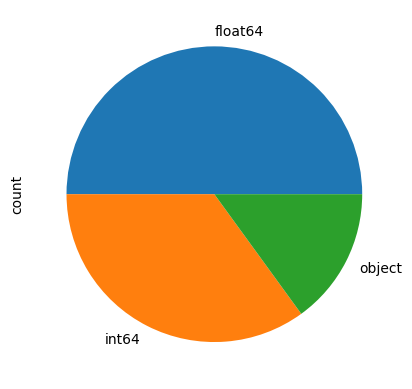

In [27]:
X_train.dtypes.value_counts().plot.pie()

In [31]:
# Valeurs manquantes
X_train.isnull().sum()


ID                       0
ID_ven                   0
dt_départ                0
dt_arrivée               0
nb_pass                  0
dist_trajet              0
code_tarif               0
données_différé          0
ID_dep                   0
ID_arr                   0
type_paie                0
supplément               0
taxe_mta                 0
péages                   0
suppl_amélioration       0
montant_total            0
duree_moy                0
dist_moy                 0
tarif_prédit             0
ratio_tip/fare_amount    6
dtype: int64

**Interpretation:** On remarque six missing values dans la colonne que nous 'ratio_tip/amount'

<Axes: >

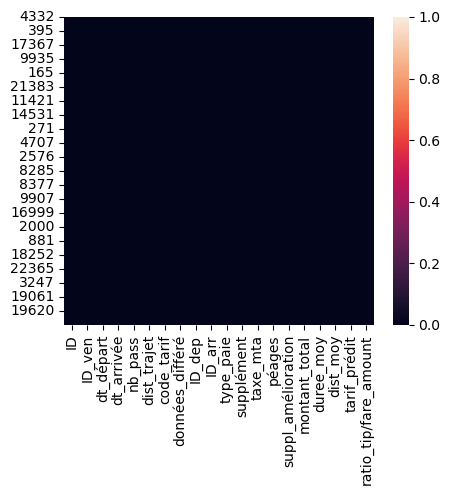

In [36]:
# Set the figure size
plt.figure(figsize=(5, 4))  

# Create a heatmap to visualize missing values
sns.heatmap(X_train.isna() , cbar=True) 

 **Interpretation**:
Le dataset est complet et ne contient presque aucune valeur manquante

In [40]:
#Séparation des variables catégorielles et des variables numériques

num_col=X_train.select_dtypes(include=['int', 'float']).columns
cat_col=X_train.select_dtypes(include=['object']).columns

print(f'Les colonnes numériques sont: {list(num_col)}')
print ('\n')
print(f'Les colonnes catégorielles sont: {list(cat_col)}')

Les colonnes numériques sont: ['ID', 'ID_ven', 'nb_pass', 'dist_trajet', 'code_tarif', 'ID_dep', 'ID_arr', 'type_paie', 'supplément', 'taxe_mta', 'péages', 'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy', 'tarif_prédit', 'ratio_tip/fare_amount']


Les colonnes catégorielles sont: ['dt_départ', 'dt_arrivée', 'données_différé']


### 1) Analyse Multivariée

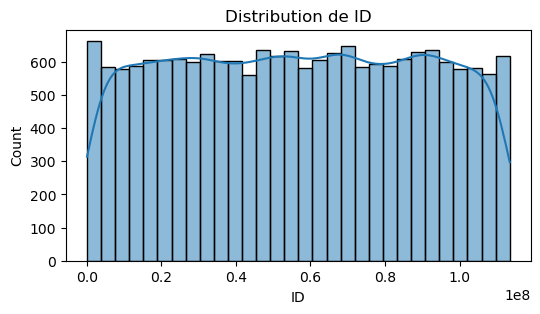

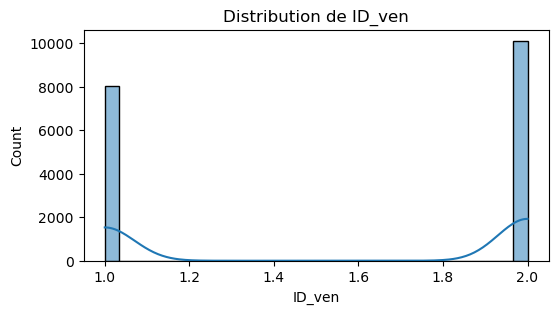

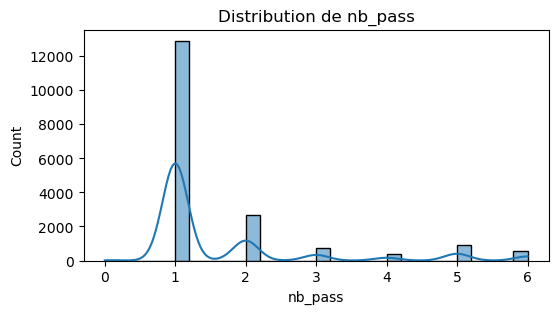

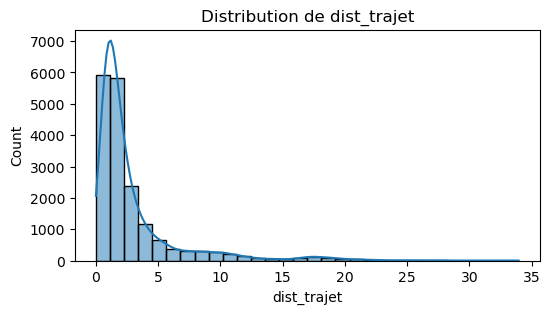

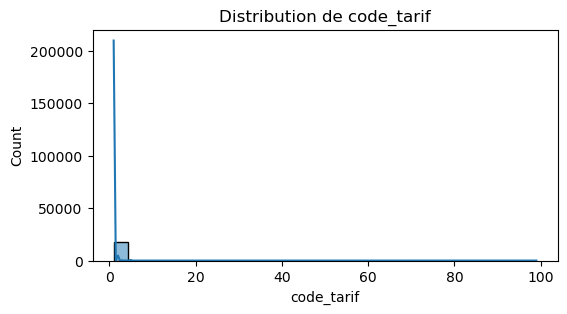

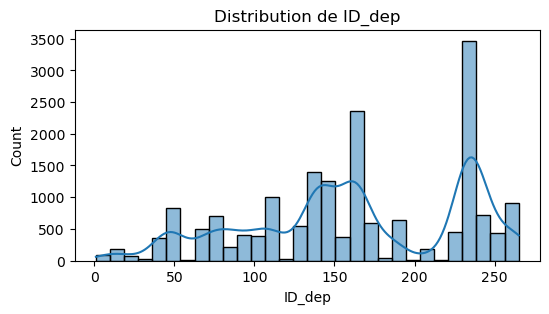

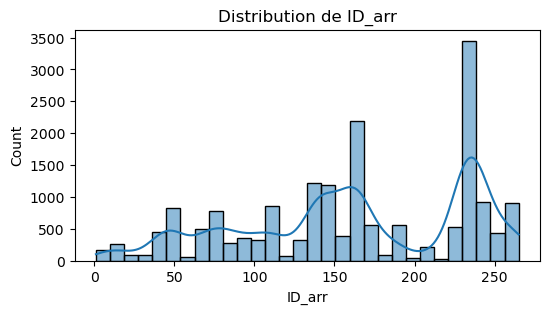

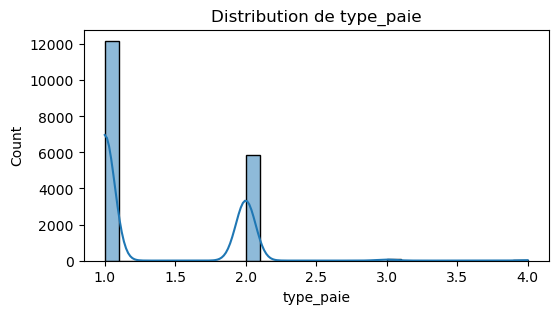

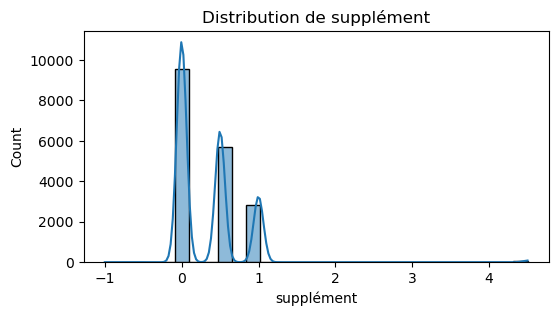

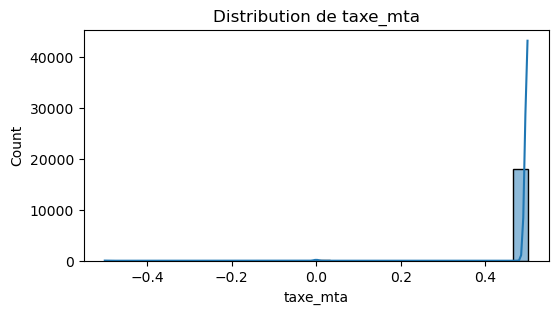

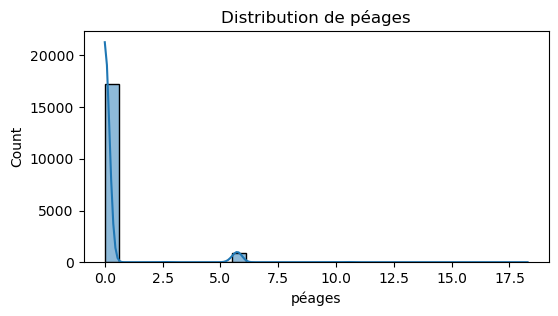

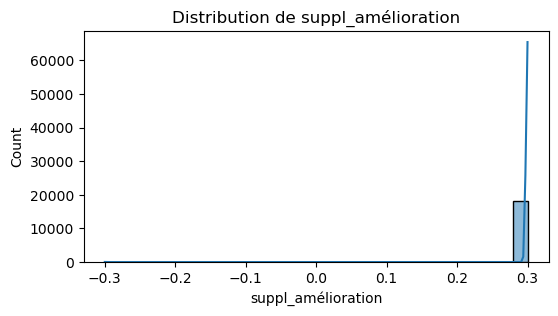

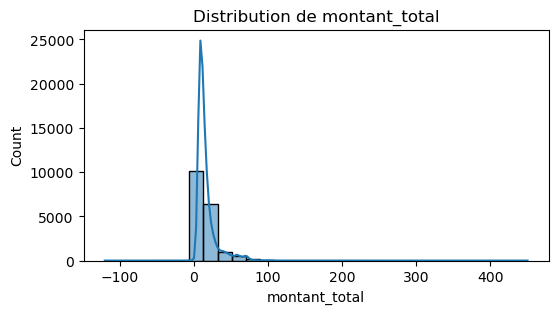

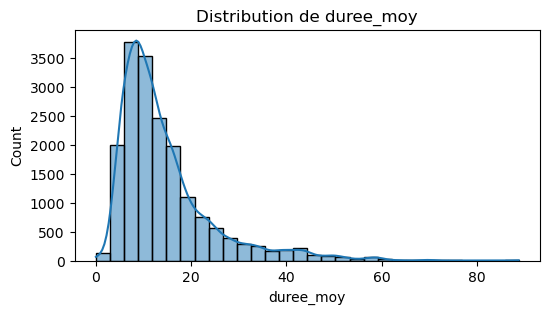

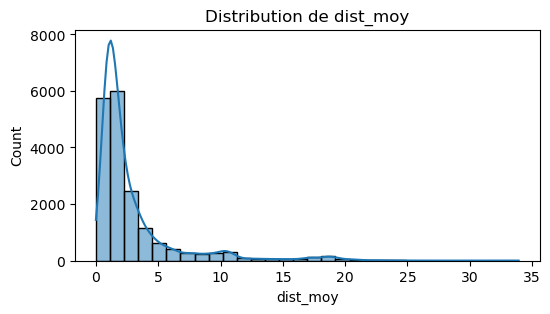

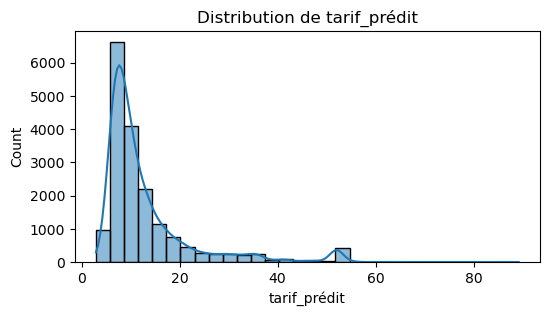

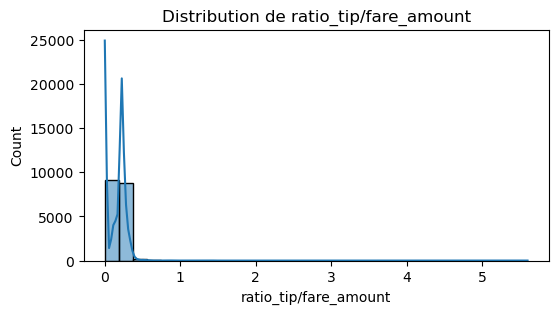

In [42]:
#Distributions des variables numériques:

for col in num_col:
    plt.figure(figsize=(6, 3))
    sns.histplot(X_train[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
    plt.show()

**Interpretation:** Nos colonnes numérique ne suivent pas une distributioon gaussienne et on peut aussi remarquer que les données ne sont pas centrées ni reduites

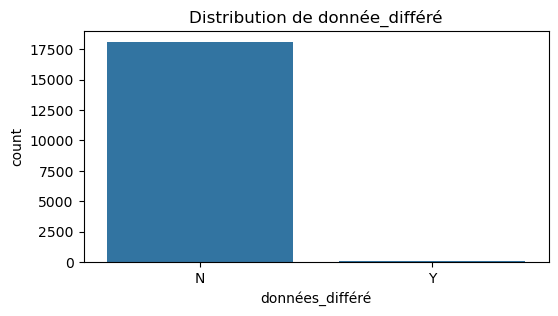

In [45]:

# Distribution des variables catégorielles:
plt.figure(figsize=(6, 3))

sns.countplot( data=X_train, x='données_différé') # Accès direct à la colonne via son nom

plt.title('Distribution de donnée_différé')
plt.show()  # Pour afficher le graphique


**Remarque:** On ne peut visualiser que cette variable de type 'object' car les autres sont des datetime et ne peuvent pas être visualisées

In [48]:

# Fonction pour détecter les outliers dans un DataFrame(Méthode d'interquantile)

def detect_outliers(X_train, columns):
    outliers_columns = []
    for col in columns:
        # Calcul de l'IQR pour chaque colonne
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Définition des bornes
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Détection des outliers : valeurs en dehors des bornes
        if ((X_train[col] < lower_bound) | (X_train[col] > upper_bound)).any():
            outliers_columns.append(col)

    return outliers_columns

# Appliquer la fonction sur les colonnes numériques
outliers_columns = detect_outliers(X_train, num_col)

# Afficher les colonnes contenant des outliers
print("Colonnes avec des outliers :")
print(outliers_columns)


Colonnes avec des outliers :
['nb_pass', 'dist_trajet', 'code_tarif', 'type_paie', 'supplément', 'taxe_mta', 'péages', 'suppl_amélioration', 'montant_total', 'duree_moy', 'dist_moy', 'tarif_prédit', 'ratio_tip/fare_amount']


**Interpretation:** Dans le préprocessing, on effectuera la standartisation et non la normalisation car les données contiennes assez de Outliers

C:\Users\User\AppData\Local\Temp\ipykernel_23188\4006062106.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_corr['client_généreux'] = y_train  # Ajout de y_train


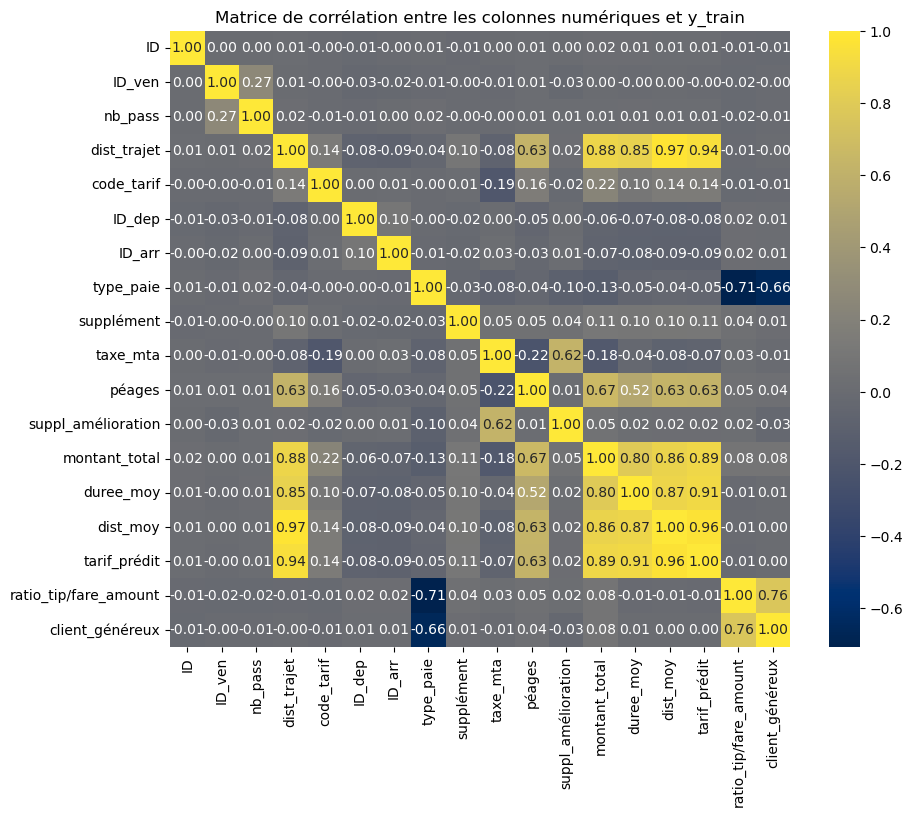

In [50]:
# Calculer la matrice de corrélation entre les colonnes numériques

# Ajouter y_train aux colonnes numériques pour la corrélation
X_train_corr = X_train[num_col]  # Copie des colonnes numériques
X_train_corr['client_généreux'] = y_train  # Ajout de y_train

# Calculer la matrice de corrélation
corr_matrix = X_train_corr.corr()

# Visualisation de la matrice de corrélation avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='cividis', fmt=".2f")
plt.title("Matrice de corrélation entre les colonnes numériques et y_train")
plt.show()


**Interpretations:**
- Le jeu de données contient plusieurs colonnes fortement correlées entre elles
- La target est assez liée à quelques features
- Le data contient énormemnt de colonnes inutiles

  Les cas mentionnés ci_dessus seront traité dans la partie préprocessing

### 2) Analyse Bivariée

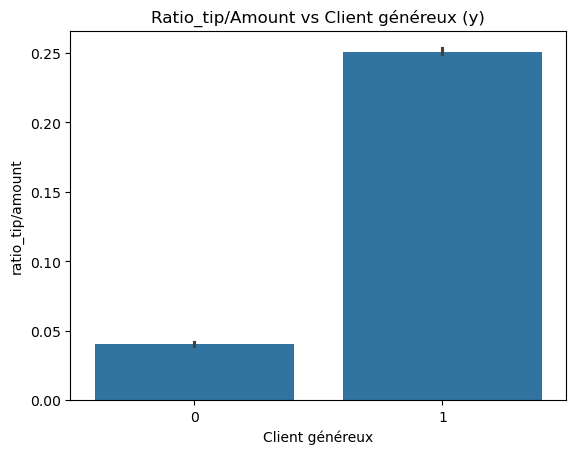

In [57]:
# Distribution de ratio_tip/amount selon y=Target
sns.barplot(x=y, y=X_train["ratio_tip/fare_amount"])
plt.title("Ratio_tip/Amount vs Client généreux (y)")
plt.xlabel("Client généreux")
plt.ylabel("ratio_tip/amount")
plt.show()


**Interpretation:** La générosité des clients est assez liée à ce ratio comme vu dans la matrice de correlation

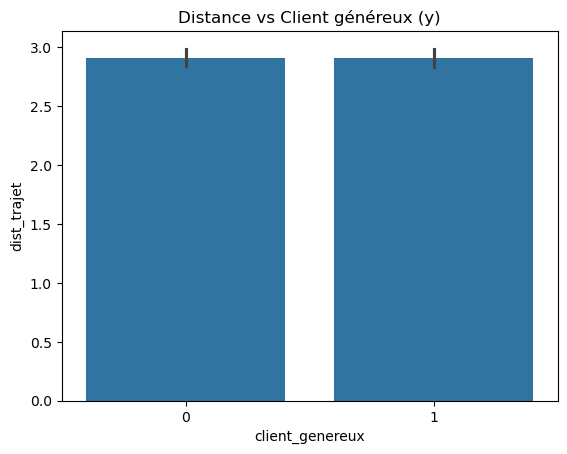

In [59]:
#Distribution de Distance_trajet selon y

sns.barplot(x=y, y=X_train["dist_trajet"])
plt.title("Distance vs Client généreux (y)")
plt.show()

**Interpretation:** Pas d'importance considéravle

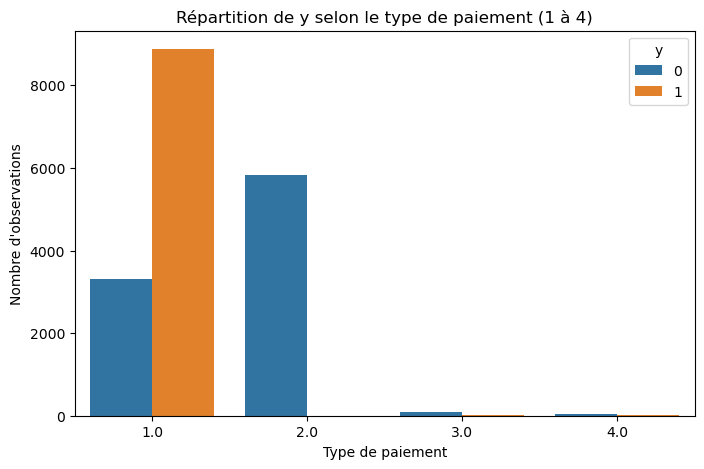

In [62]:
#Proportion de clients généreux selon le type de paie

plt.figure(figsize=(8, 5))
sns.countplot(x=X_train["type_paie"], hue=y)
plt.title("Répartition de y selon le type de paiement (1 à 4)")
plt.xlabel("Type de paiement")
plt.ylabel("Nombre d'observations")
plt.legend(title="y")


**Interpretation:** la majorité des clients paient avec les types 1 et 2, les clients généreux sont moins fréquents dans tous les cas.. Les types de paiement 3 et 4 ont très peu d'observations pour les deux catégories.



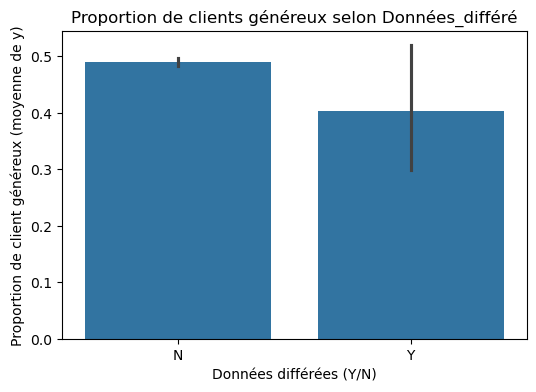

In [65]:
plt.figure(figsize=(6, 4))
sns.barplot(x=X_train["données_différé"], y=y)
plt.title("Proportion de clients généreux selon Données_différé")
plt.xlabel("Données différées (Y/N)")
plt.ylabel("Proportion de client généreux (moyenne de y)")
plt.show()

**Interpretation:** Les clients généreux sont proportionnellement plus nombreux lorsque les données ne sont pas différées ("N"). En revanche, la proportion diminue lorsque les données sont différées ("Y").



# <font color='brown'>IV. PREPROCESSING </font>

## 1. Netoyage de dataset

In [71]:
# Suppression des la colonne inutiles
X_train = X_train.drop(columns=["ID_dep", "ID_arr"], axis=1)

#### Gestion des valeurs manquantes

In [74]:
# Vérification des valeurs manquantes
print(X_train.isnull().sum())

# Remplissage des valeurs manquantes (exemple avec la colonne 'ratio_tip/amount')
X_train['ratio_tip/fare_amount'].fillna(X_train['ratio_tip/fare_amount'].mean(), inplace=True)


ID                       0
ID_ven                   0
dt_départ                0
dt_arrivée               0
nb_pass                  0
dist_trajet              0
code_tarif               0
données_différé          0
type_paie                0
supplément               0
taxe_mta                 0
péages                   0
suppl_amélioration       0
montant_total            0
duree_moy                0
dist_moy                 0
tarif_prédit             0
ratio_tip/fare_amount    6
dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_23188\3433288432.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['ratio_tip/fare_amount'].fillna(X_train['ratio_tip/fare_amount'].mean(), inplace=True)


#### Traitement des outliers

In [77]:
def remove_outliers(X_train, columns):
    for col in columns:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        X_train = X_train[(X_train[col] >= lower_bound) & (X_train[col] <= upper_bound)]
    return X_train


In [79]:
num_col=X_train.select_dtypes(include=['int', 'float']).columns
X_train = remove_outliers(X_train, num_col)


In [81]:
X_train

,ID,ID_ven,dt_départ,dt_arrivée,nb_pass,dist_trajet,code_tarif,données_différé,type_paie,supplément,taxe_mta,péages,suppl_amélioration,montant_total,duree_moy,dist_moy,tarif_prédit,ratio_tip/fare_amount
4332,13257587,1,02/19/2017 10:53:20 AM,02/19/2017 11:00:57 AM,1,1.00,1,N,1,0.0,0.5,0.0,0.3,8.75,9.624444,1.174667,8.058624,0.223077
16775,62014879,1,07/21/2017 1:56:13 PM,07/21/2017 2:03:57 PM,1,1.30,1,N,1,0.0,0.5,0.0,0.3,9.35,11.307619,1.478857,9.134329,0.221429
4417,94465869,2,11/08/2017 7:39:50 AM,11/08/2017 7:53:04 AM,3,2.27,1,N,1,0.0,0.5,0.0,0.3,12.80,16.131667,2.394000,12.483611,0.090909
7027,29356846,2,04/08/2017 8:36:23 PM,04/08/2017 8:52:12 PM,1,1.64,1,N,1,0.5,0.5,0.0,0.3,14.76,12.547500,1.412500,9.237680,0.223636
19521,50589525,1,06/15/2017 11:02:45 AM,06/15/2017 11:16:43 AM,1,1.30,1,N,1,0.0,0.5,0.0,0.3,12.95,13.842857,1.577143,10.036362,0.215000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19030,79550235,1,09/21/2017 10:23:20 PM,09/21/2017 10:36:41 PM,1,2.50,1,N,2,0.5,0.5,0.0,0.3,12.80,14.844444,3.483333,14.119318,0.000000
9711,100321490,1,11/27/2017 1:46:22 PM,11/27/2017 1:55:02 PM,1,1.90,1,N,2,0.0,0.5,0.0,0.3,9.30,8.873810,1.686429,8.870920,0.000000
3188,64001542,2,07/28/2017 9:30:25 AM,07/28/2017 9:39:34 AM,1,0.88,1,N,1,0.0,0.5,0.0,0.3,8.80,5.880702,0.791579,6.383697,0.142857
3611,54747933,1,06/27/2017 10:55:05 AM,06/27/2017 11:05:11 AM,1,1.50,1,N,1,0.0,0.5,0.0,0.3,11.15,12.307576,1.815455,10.084478,0.217647


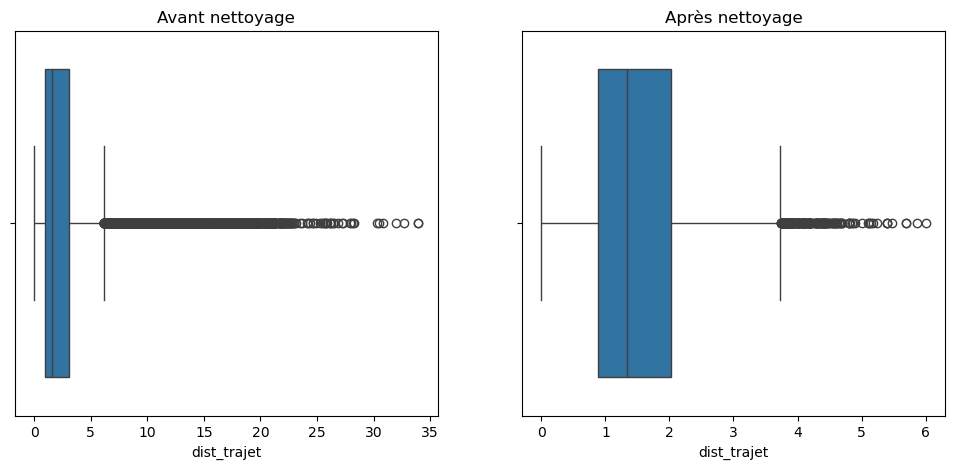

In [83]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df["dist_trajet"])
plt.title("Avant nettoyage")

plt.subplot(1, 2, 2)
sns.boxplot(x=X_train["dist_trajet"])
plt.title("Après nettoyage")

plt.show()


## 2. Encodage des variables catégorielles

In [86]:
#Encodage de seule colonne catégorielle restante
df['données_différé'] = df['données_différé'].map({'Y': 1, 'N': 0})


In [88]:
df

,ID,ID_ven,dt_départ,dt_arrivée,nb_pass,dist_trajet,code_tarif,données_différé,ID_dep,ID_arr,...,supplément,taxe_mta,péages,suppl_amélioration,montant_total,duree_moy,dist_moy,tarif_prédit,client_genereux,ratio_tip/fare_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,0,100,231,...,0.0,0.5,0.00,0.3,16.56,22.847222,3.521667,16.434245,1,0.212308
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,0,186,43,...,0.0,0.5,0.00,0.3,20.80,24.470370,3.108889,16.052218,1,0.250000
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,0,262,236,...,0.0,0.5,0.00,0.3,8.75,7.250000,0.881429,7.053706,1,0.223077
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,0,188,97,...,0.0,0.5,0.00,0.3,27.69,30.250000,3.700000,18.731650,1,0.311707
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,0,4,112,...,0.5,0.5,0.00,0.3,17.80,14.616667,4.435000,15.845642,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22694,14873857,2,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,3,0.61,1,0,48,186,...,1.0,0.5,0.00,0.3,5.80,8.594643,1.098214,7.799138,0,0.000000
22695,66632549,2,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,1,16.71,2,0,132,164,...,0.0,0.5,5.76,0.3,73.20,59.560417,18.757500,52.000000,1,0.281538
22696,74239933,2,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,1,0.42,1,0,107,234,...,0.0,0.5,0.00,0.3,5.30,6.609091,0.684242,6.130896,0,0.000000
22697,60217333,2,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,1,2.36,1,0,68,144,...,0.0,0.5,0.00,0.3,13.00,16.650000,2.077500,11.707049,0,0.161905


## 3. Feature Engineering

#### Création de nouvelles variables à partir des dates

In [94]:
# Convertit les colonnes de dates en objets datetime
X_train['dt_départ'] = pd.to_datetime(X_train['dt_départ'])
X_train['dt_arrivée'] = pd.to_datetime(X_train['dt_arrivée'])

# Calcule la durée du trajet en minutes
X_train['duree_trajet'] = (X_train['dt_arrivée'] - X_train['dt_départ']).dt.total_seconds() / 60

In [96]:
#Suppression des colonne déjà expploitées et inutiles

X_train = X_train.drop(columns=["dt_départ", "dt_arrivée"], axis=1)

In [104]:
#Correlation entre la var crée et la target
X_train['duree_trajet'].corr(y)

-0.027489006161977924

## 4. Sélection des features avec la matrice de correlation

In [110]:
Three_Best_Cols = ['ratio_tip/fare_amount', 'montant_total', 'type_paie']

# Réduction du dataset
X_train_selected = X_train[Three_Best_Cols]

print(X_train_selected)

       ratio_tip/fare_amount  montant_total  type_paie
4332                0.223077           8.75          1
16775               0.221429           9.35          1
4417                0.090909          12.80          1
7027                0.223636          14.76          1
19521               0.215000          12.95          1
...                      ...            ...        ...
19030               0.000000          12.80          2
9711                0.000000           9.30          2
3188                0.142857           8.80          1
3611                0.217647          11.15          1
4428                0.240000           5.76          1

[12949 rows x 3 columns]


## 5. Rééquilibrage des classes 

In [219]:
from imblearn.over_sampling import SMOTE

# Vérifie combien il y a de "0" et de "1"
print(df['client_genereux'].value_counts())

client_genereux
0    20796
1     1903
Name: count, dtype: int64


In [86]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_train, y_train)

ValueError: could not convert string to float: '05/27/2017 1:09:31 PM'

## 6. Standardisation

In [ ]:
df_original = df.copy()

In [ ]:
# Standardisation des variables numériques
scaler = StandardScaler()
num_cols = ['dist_trajet', 'montant_course', 'duree_moy', 'dist_moy', 'tarif_prédit']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Vérification
print(df[num_cols].describe())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Avant standardisation
sns.boxplot(data=df_original[num_cols], ax=axes[0], palette="pastel", showfliers=False)
axes[0].set_title("🔹 Avant standardisation", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Après standardisation
sns.boxplot(data=df[num_cols], ax=axes[1], palette="Set2", showfliers=False)
axes[1].set_title("🔸 Après standardisation", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# Titre global et mise en page
plt.suptitle("Comparaison des distributions avant et après standardisation", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()